In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

# Check if we are currently inside the 'notebooks' folder
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [3]:
from src.config import SimConfig
from src.utils.data_processing import load_and_cache_entire_fleet
from src.utils.evaluation import VoyageBenchmarker, print_markdown_table
from src.utils.plotting import plot_simulation_dashboard, plot_benchmarker_results, plot_markov_matrix

from src.solvers import AugmentedHybridSDPSolver, AugmentedBaselineSDPSolver

from src.plants import AugmentedHybridPlant, AugmentedFuelCellOnlyPlant

from src.controllers import (
    build_approach,
    AugmentedFCLockedControl,
    AugmentedPolicyControl,
    AugmentedValueControl,
    AugmentedSDPBaselineControl
)

config = SimConfig()
fleet_data = load_and_cache_entire_fleet(config)

# Initialize benchmarker
exclude_days = [] 
benchmarker = VoyageBenchmarker(fleet_data, config, exclude_days)

Beginning memory staging of all 14 fleet files into RAM...
 -> Day 01 successfully cached in RAM.
 -> Day 02 successfully cached in RAM.
 -> Day 03 successfully cached in RAM.
 -> Day 04 successfully cached in RAM.
 -> Day 05 successfully cached in RAM.
 -> Day 06 successfully cached in RAM.
 -> Day 07 successfully cached in RAM.
 -> Day 08 successfully cached in RAM.
 -> Day 09 successfully cached in RAM.
 -> Day 10 successfully cached in RAM.
 -> Day 11 successfully cached in RAM.
 -> Day 12 successfully cached in RAM.
 -> Day 13 successfully cached in RAM.
 -> Day 14 successfully cached in RAM.

All 14 operational days securely held in RAM. Disk I/O locked.


In [4]:
augmented_approaches = {
    # "MacroFuelCellOnlyBaseline": build_approach(
    #     plant_cls=AugmentedFuelCellOnlyPlant,
    #     controller_cls=AugmentedSDPBaselineControl,
    #     solver_cls=AugmentedBaselineSDPSolver,
    #     is_macro=True
    # ),
    # "FuelCellOnlyBaseline": build_approach(
    #     plant_cls=AugmentedFuelCellOnlyPlant,
    #     controller_cls=AugmentedSDPBaselineControl,
    #     solver_cls=AugmentedBaselineSDPSolver,
    #     is_macro=False
    # ),
    # "MacroHybridBaseline": build_approach(
    #     plant_cls=AugmentedHybridPlant,
    #     controller_cls=AugmentedSDPBaselineControl,
    #     solver_cls=AugmentedBaselineSDPSolver,
    #     is_macro=True
    # ),
    # "HybridBaseline": build_approach(
    #     plant_cls=AugmentedHybridPlant,
    #     controller_cls=AugmentedSDPBaselineControl,
    #     solver_cls=AugmentedBaselineSDPSolver,
    #     is_macro=False
    # ),
    "MacroFCLocked": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedFCLockedControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=True
    ),
    # "FCLocked": build_approach(
    #     plant_cls=AugmentedHybridPlant,
    #     controller_cls=AugmentedFCLockedControl,
    #     solver_cls=AugmentedHybridSDPSolver,
    #     is_macro=False
    # ),
    "MacroPolicy": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedPolicyControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=True
    ),
    # "Policy": build_approach(
    #     plant_cls=AugmentedHybridPlant,
    #     controller_cls=AugmentedPolicyControl,
    #     solver_cls=AugmentedHybridSDPSolver,
    #     is_macro=False
    # ),
    "MacroValue": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedValueControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=True
    ),
    # "Value": build_approach(
    #     plant_cls=AugmentedHybridPlant,
    #     controller_cls=AugmentedValueControl,
    #     solver_cls=AugmentedHybridSDPSolver,
    #     is_macro=False
    # ),
}

 [Vault] Cache MISS: Training Markov Chain for days [1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...


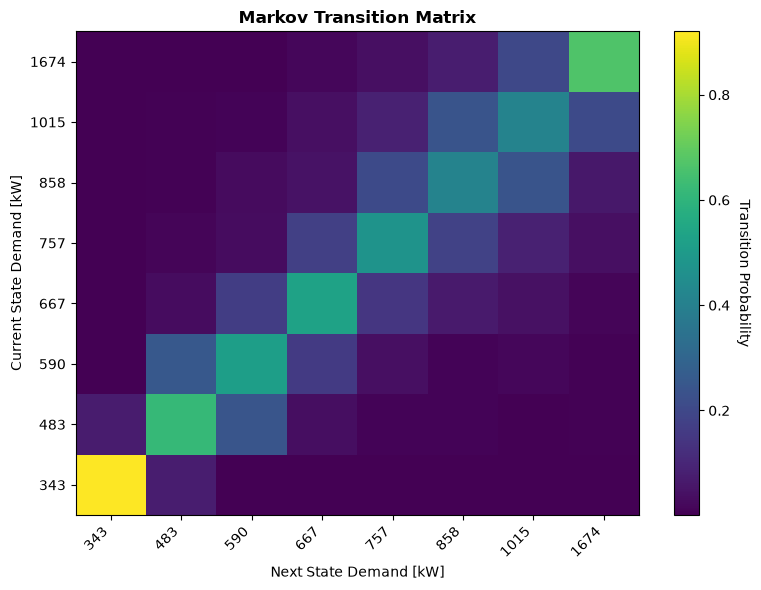

In [5]:
# Manually choose training block and test validation target
train_days = [1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
mc_model, _, _ = benchmarker._get_or_compute_models(train_days, solver_cls=None, horizon_length=1)
plot_markov_matrix(mc_model)
test_day = 4
approaches = augmented_approaches

--- APPROACH A: HAND-PICKED EVALUATION ---
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
| Strategy      | Total Cost [€] | Operating Cost [€] | Switching Cost [€] | Battery Cost [€] | Transient Cost [€] | Term. Switch Cost [€] | Term. SoC Cost [€] | Offline Compute Time [s] | Online Compute Time [s] |
|---------------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| MacroFCLocked | 6882.47        | 5783.77            | 675.00             | 61.41            | 197.68             | 75.00                 | 89.61              | 74.37                    | 0.09                    |
| MacroPolicy   | 6854.36        | 5878.00            | 600.00             | 60.42            | 186.29             | 150.00                | -20.34             | 74.37                    | 0.02                    |
| MacroValue    |

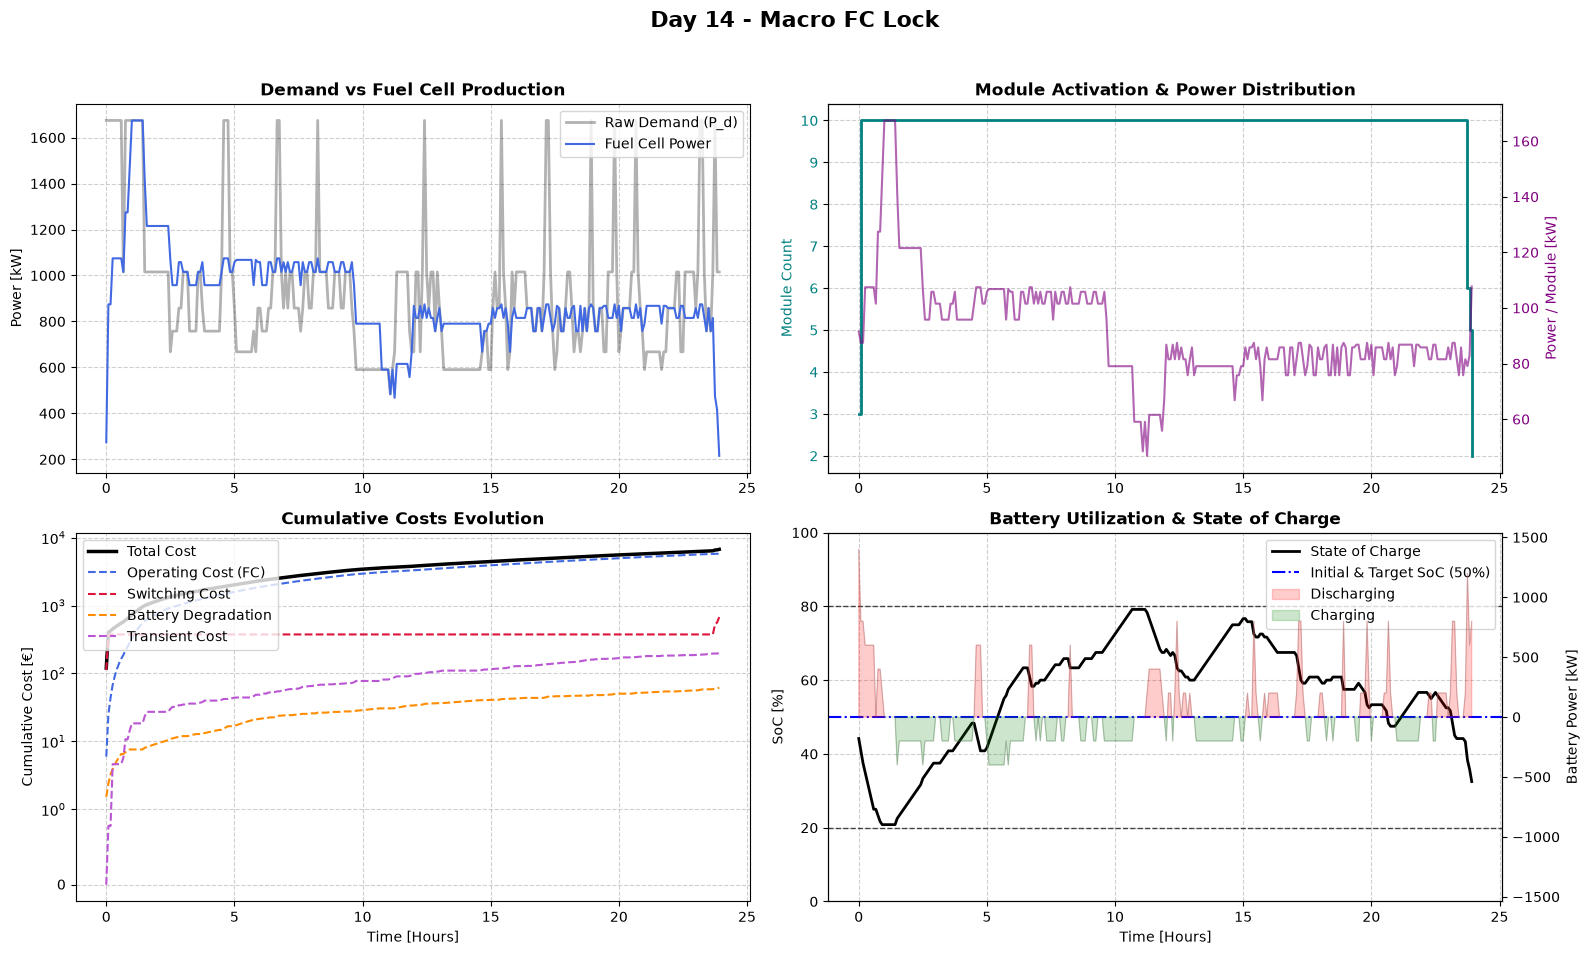

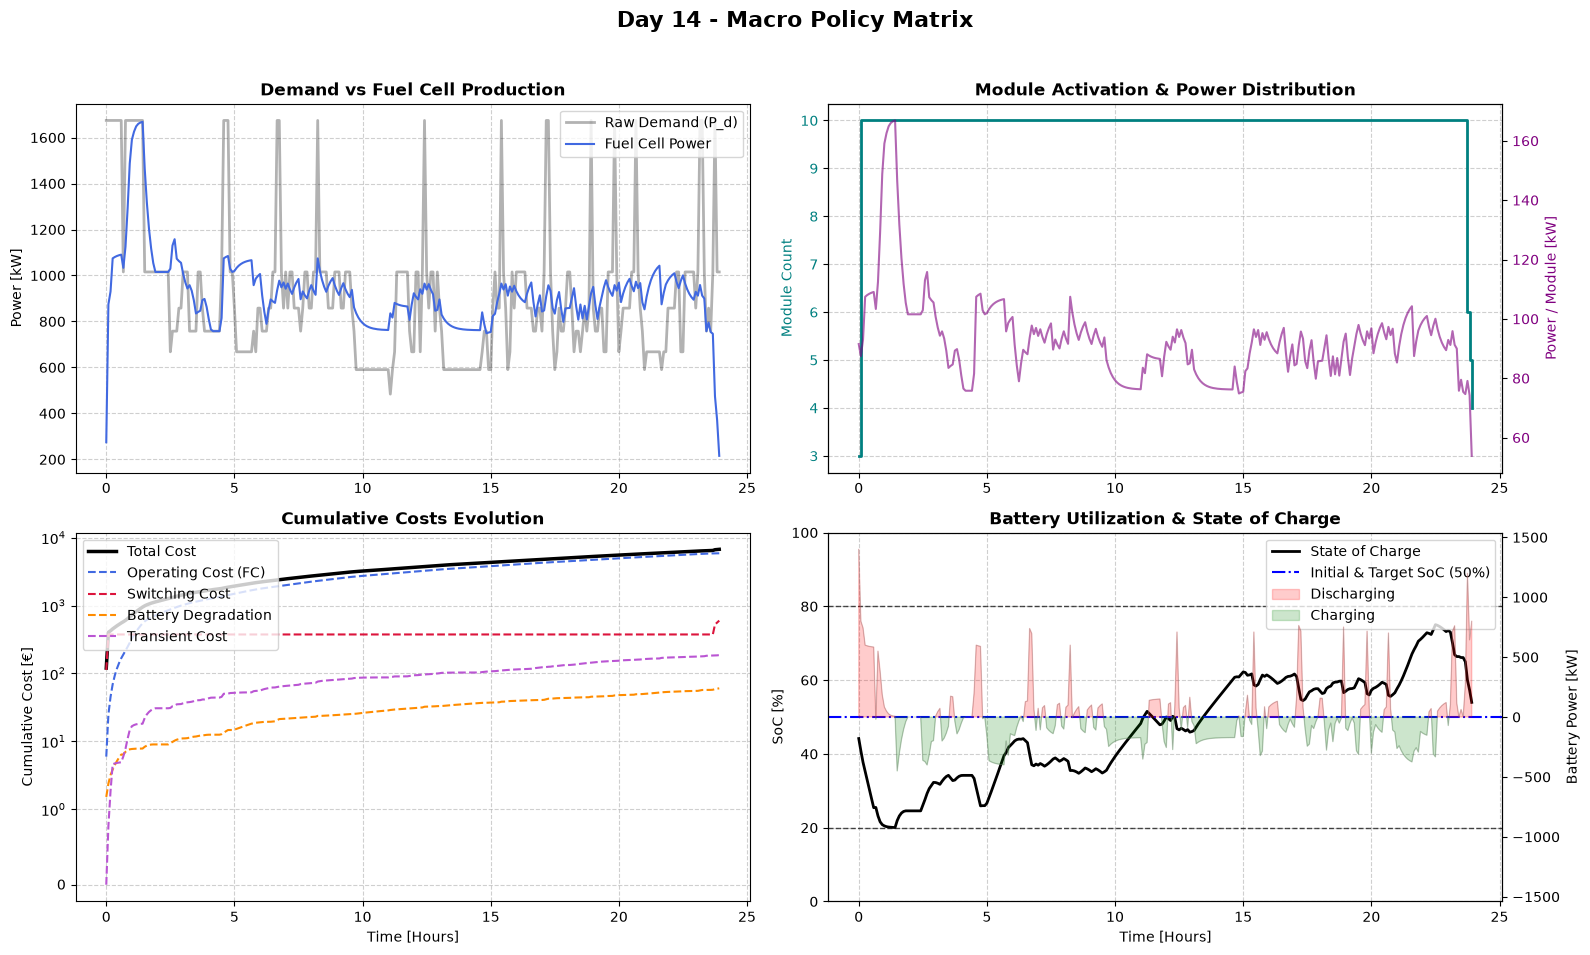

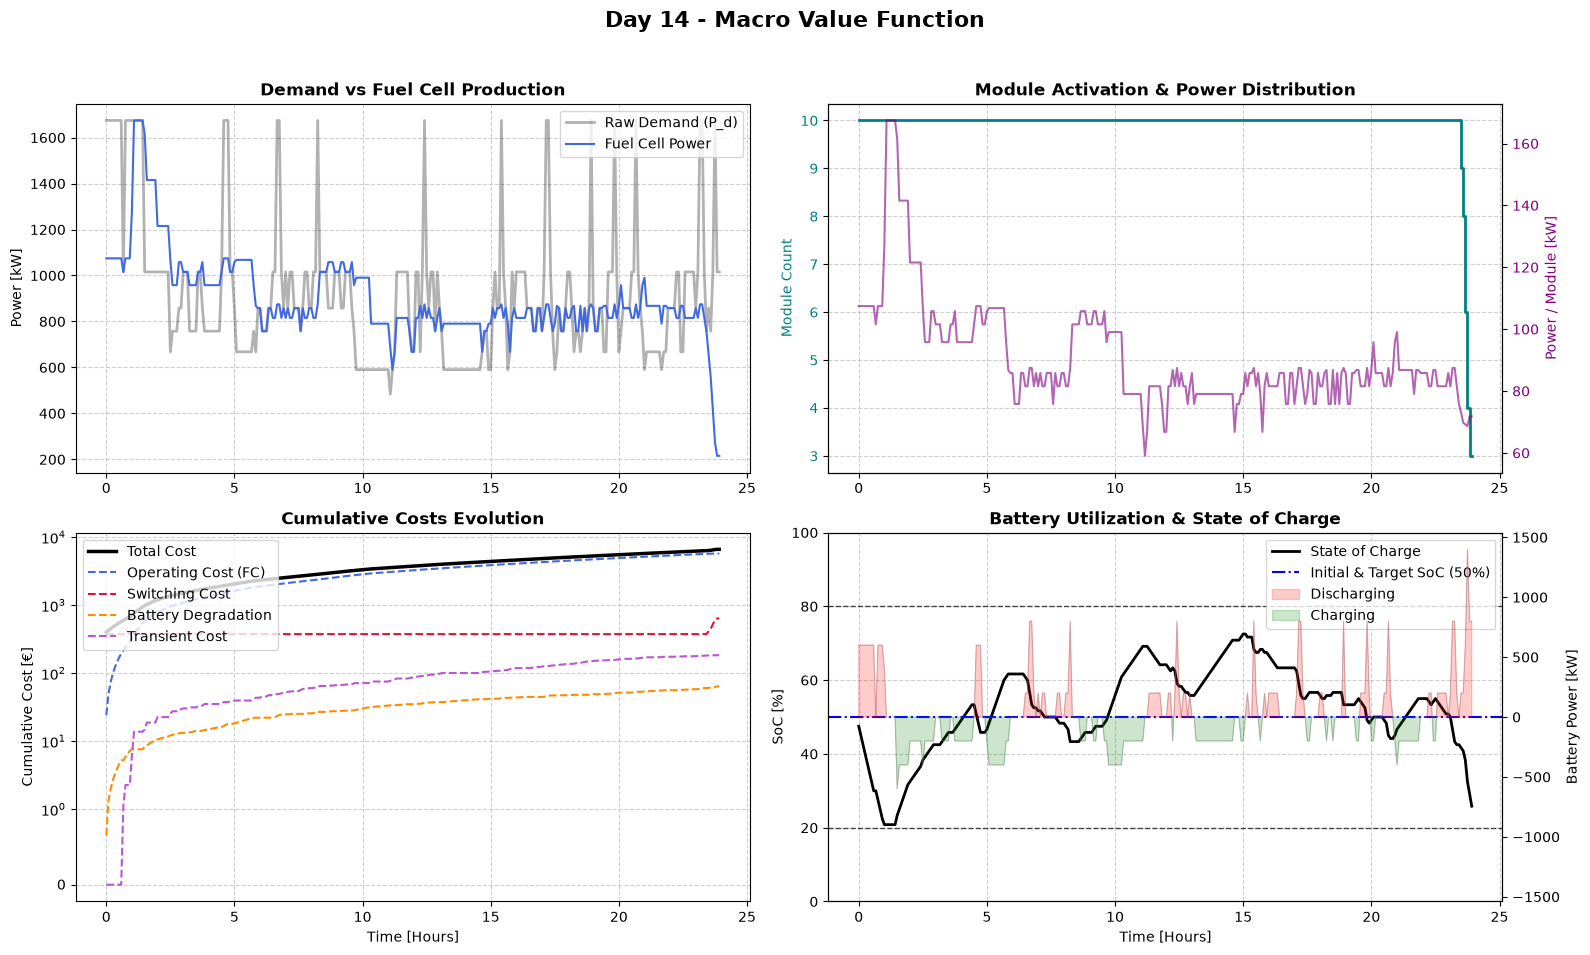

In [6]:
print("--- APPROACH A: HAND-PICKED EVALUATION ---")

report = benchmarker.compare_approaches(approaches, train_days, test_day)
print_markdown_table(report.summary)


# plot_simulation_dashboard(report.get_telemetry("MacroFuelCellOnlyBaseline"), benchmarker.config, title="Day 14 - Macro Baseline", indiv=False)
# plot_simulation_dashboard(report.get_telemetry("FuelCellOnlyBaseline"), benchmarker.config, title="Day 14 - Micro Baseline", indiv=False)
# plot_simulation_dashboard(report.get_telemetry("MacroHybridBaseline"), benchmarker.config, title="Day 14 - Macro Hybrid Baseline", indiv=False)
# plot_simulation_dashboard(report.get_telemetry("HybridBaseline"), benchmarker.config, title="Day 14 - Micro Hybrid Baseline", indiv=False)
plot_simulation_dashboard(report.get_telemetry("MacroFCLocked"), benchmarker.config, title="Day 14 - Macro FC Lock", indiv=False)
# plot_simulation_dashboard(report.get_telemetry("FCLocked"), benchmarker.config, title="Day 14 - Micro FC Lock", indiv=False)
plot_simulation_dashboard(report.get_telemetry("MacroPolicy"), benchmarker.config, title="Day 14 - Macro Policy Matrix", indiv=False)
# plot_simulation_dashboard(report.get_telemetry("Policy"), benchmarker.config, title="Day 14 - Micro Policy Matrix", indiv=False)
plot_simulation_dashboard(report.get_telemetry("MacroValue"), benchmarker.config, title="Day 14 - Macro Value Function", indiv=False)
# plot_simulation_dashboard(report.get_telemetry("Value"), benchmarker.config, title="Day 14 - Micro Value Function", indiv=False)




--- APPROACH B: LEAVE-ONE-OUT (Discrete Tracking vs Baseline) ---
 [Vault] Cache MISS: Training Markov Chain for days [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Mar

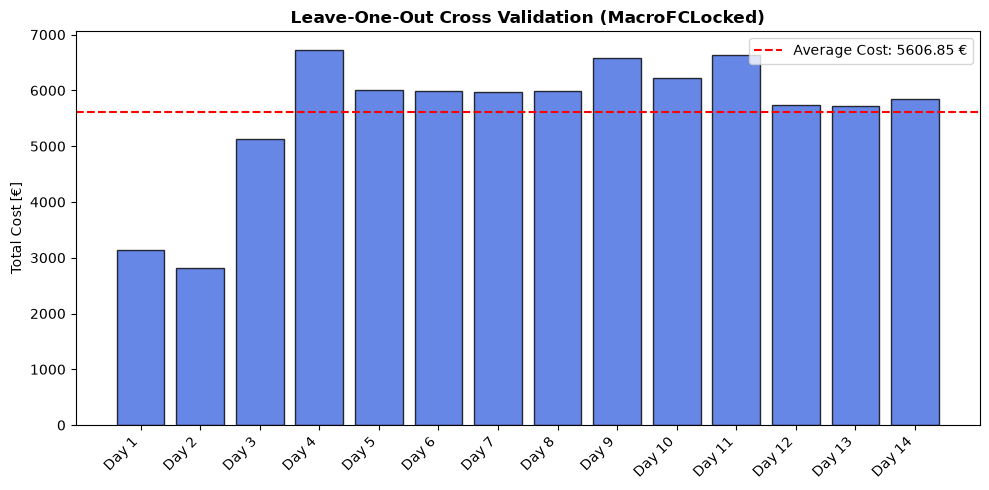

| Strategy | Total Cost [€] | Operating Cost [€] | Switching Cost [€] | Battery Cost [€] | Transient Cost [€] | Term. Switch Cost [€] | Term. SoC Cost [€] | Offline Compute Time [s] | Online Compute Time [s] |
|----------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Day 1    | 3130.17        | 2588.83            | 487.50             | 13.02            | 56.33              | 112.50                | -128.01            | 62.73                    | 0.00                    |
| Day 2    | 2823.96        | 2464.64            | 337.50             | 11.72            | 42.69              | 112.50                | -145.08            | 62.54                    | 0.00                    |
| Day 3    | 5122.30        | 4221.70            | 337.50             | 23.22            | 53.03              | 337.50                | 149.35             | 74.

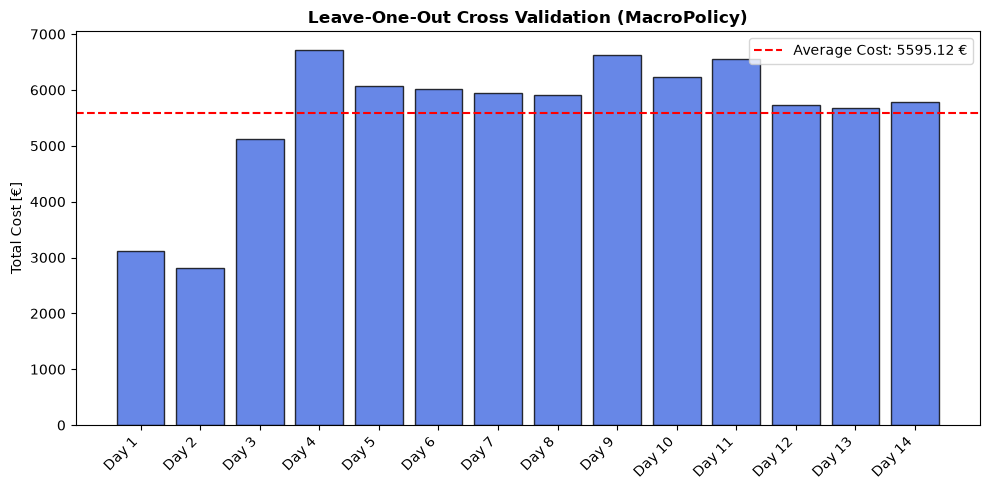

| Strategy | Total Cost [€] | Operating Cost [€] | Switching Cost [€] | Battery Cost [€] | Transient Cost [€] | Term. Switch Cost [€] | Term. SoC Cost [€] | Offline Compute Time [s] | Online Compute Time [s] |
|----------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Day 1    | 3123.86        | 2611.72            | 525.00             | 12.70            | 42.85              | 75.00                 | -143.40            | 62.73                    | 0.00                    |
| Day 2    | 2810.37        | 2464.80            | 337.50             | 10.16            | 36.17              | 112.50                | -150.76            | 62.54                    | 0.00                    |
| Day 3    | 5124.35        | 4225.18            | 337.50             | 27.21            | 43.35              | 337.50                | 153.62             | 74.

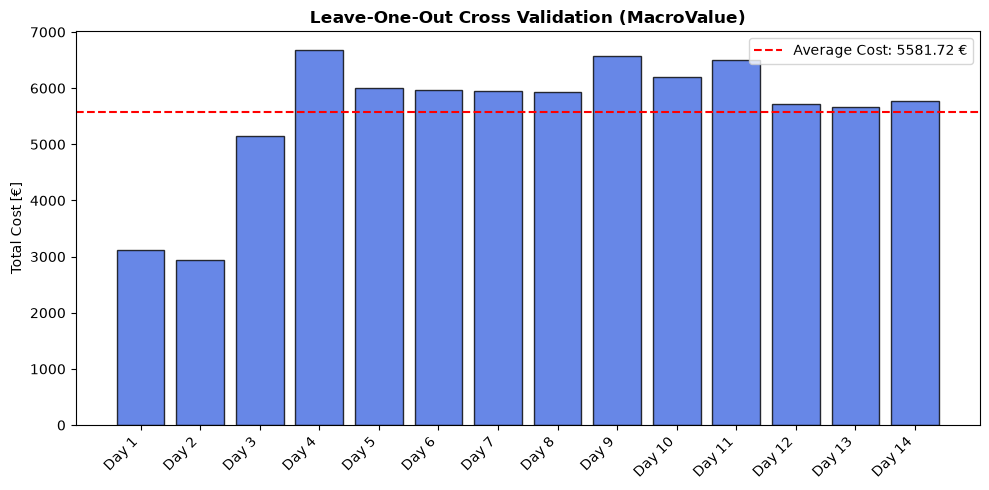

| Strategy | Total Cost [€] | Operating Cost [€] | Switching Cost [€] | Battery Cost [€] | Transient Cost [€] | Term. Switch Cost [€] | Term. SoC Cost [€] | Offline Compute Time [s] | Online Compute Time [s] |
|----------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Day 1    | 3125.40        | 2597.32            | 450.00             | 9.11             | 46.99              | 150.00                | -128.01            | 62.73                    | 0.01                    |
| Day 2    | 2936.42        | 2509.81            | 262.50             | 14.32            | 40.90              | 262.50                | -153.62            | 62.54                    | 0.01                    |
| Day 3    | 5143.59        | 4220.26            | 337.50             | 23.22            | 75.76              | 337.50                | 149.35             | 74.

In [7]:
print("\n--- APPROACH B: LEAVE-ONE-OUT (Discrete Tracking vs Baseline) ---")

# Note: Running LOO on all 5 approaches might take a couple of minutes due to 4D solves.
# Let's compare the main engineering deployable hybrid against the legacy baseline.

for app in approaches:
# for app in ["Value"]:
    report = benchmarker.run_leave_one_out(approaches[app])
    plot_benchmarker_results(report.summary, title=f"Leave-One-Out Cross Validation ({app})", plot_type='bar')
    print_markdown_table(report.summary)



In [ ]:
print("\n--- APPROACH C: FORWARD CHAINING (Learning Curve) ---")
# Evaluate how the policy improves as the agent gathers chronological data
# Using the Lookahead Optimum to see the absolute theoretical ceiling of the ship's capabilities

for app in approaches:
# for app in ["Value"]:
    report = benchmarker.run_forward_chaining(approaches[app])
    plot_benchmarker_results(report.summary, title=f"Forward Chaining Learning Curve ({app})", plot_type='line')
    print_markdown_table(report.summary)


--- APPROACH C: FORWARD CHAINING (Learning Curve) ---
 [Vault] Cache MISS: Training Markov Chain for days [1]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [1, 2]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [1, 2, 3]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
